# The validation campaign: two estimators, three geometries, one verdict

This library ships two estimators for the probability of loss of separation (LoS). Plain
Monte Carlo (MC) flies independent encounters and counts failures. Interacting particle
splitting (IPS, ADR 0017) walks a particle cloud down a ladder of separation shells and
multiplies the survival fractions. They estimate the same number by construction, so on any
condition where both can afford an answer, the two must agree. This page reads the campaign
that checks exactly that.

The design runs three encounter geometries. A crossing **pair** swept over the crossing angle
(`dpsi`), a converging **ring** swept over its fleet size (`n`), and drawn **random traffic**
swept over density. Every condition runs at three GNSS noise rungs, a 95 % radial position
accuracy (`pos_ci95`) of 30 m, 10 m and 5 m. The 30 m rung is the anchor, common enough that
MC is unimpeachable there. The rarer rungs are where splitting has to carry the number alone.

The MC anchor sizes itself from the IPS estimate, then grows until it rests on at least 50
events or a cap of 5,000,000 encounters. IPS runs 2,000 particles and 10 replications per
condition, on shell ladders calibrated per condition by a 200-encounter pilot. Agreement is
judged on the **ratio** of the two estimates against a 95 % noise band built from a Wilson
interval on the MC side and the replication spread on the IPS side (ADR 0022 declines a
confidence interval on the IPS estimate itself).

Provenance: one run of `scripts/validation/run_campaign.py` on a 100-core machine,
2026-08-07, 14,019 s wall time. The rows below are read unmodified from
`scripts/validation/out/{pairwise,ring,random_traffic}.json`; the console log is
`campaign_fresh.log`.


In [1]:
%matplotlib inline
import json
import pathlib

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.dpi"] = 130

BLUE, RED, ORANGE, PURPLE = "#1f77b4", "#d62728", "#ff7f0e", "#9467bd"
PART_COLOR = {"pairwise": BLUE, "ring": RED, "random_traffic": ORANGE}
RUNG_MARKER = {30.0: "o", 10.0: "s", 5.0: "^"}

ROOT = pathlib.Path.cwd()
while not (ROOT / "scripts" / "validation" / "out").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
OUT = ROOT / "scripts" / "validation" / "out"

rows = []
for part in ("pairwise", "ring", "random_traffic"):
    payload = json.loads((OUT / f"{part}.json").read_text())
    for r in payload["rows"]:
        label = {k: v for k, v in r["_label"].items() if k != "pos_ci95"}
        rows.append({
            "part": part,
            "cell": ", ".join(f"{k}={v}" for k, v in label.items()),
            "rung": r["_label"]["pos_ci95"],
            "N": r["n_aircraft"],
            "mc_p": r["mc_p_los_run"],
            "mc_p_ac": r["mc_p_los_ac"],
            "events": r["mc_events"],
            "runs": r["mc_encounters"],
            "anchored": r["mc_anchored"],
            "grew": len(r.get("mc_batches", [1])) - 1,
            "ips_p": r["ips_p_los_run"],
            "ips_p_ac": r["ips_p_los_ac"],
            "collapsed": r["ips_collapsed"],
            "rel_se": r.get("ips_rel_se"),
            "ratio": r["ratio_run"],
            "band": r.get("ratio_noise95"),
            "ratio_ac": r.get("ratio_ac"),
            "mc_s": r["mc_seconds"],
            "ips_s": r["ips_seconds"],
            "gain": r["gain"],
        })

df = pd.DataFrame(rows)
print(f"{len(df)} conditions, {int(df.anchored.sum())} anchored, "
      f"{int(df.collapsed.sum())} collapsed replications of {len(df) * 10}")


36 conditions, 36 anchored, 13 collapsed replications of 360


## The rows

One row per condition. `events` and `runs` are the anchor's basis, `grew` counts how many times
it re-sized itself to reach 50 events, `collapsed` counts IPS replications that hit an empty
shell (a flagged failure, never a silent zero). `ratio` is the agreement measure and `band` is
how large a ratio pure noise explains at 95 %.


In [2]:
show = df[["part", "cell", "rung", "N", "mc_p", "events", "runs", "grew",
           "ips_p", "collapsed", "ratio", "band", "gain"]].copy()
for col in ("mc_p", "ips_p"):
    show[col] = show[col].map(lambda v: f"{v:.3e}")
show["band"] = show["band"].map(lambda v: "" if pd.isna(v) else f"{v:.2f}")
show


,part,cell,rung,N,mc_p,events,runs,grew,ips_p,collapsed,ratio,band,gain
0,pairwise,dpsi=45.0,30.0,2,4.036e-03,50,12387,0,4.037e-03,0,1.000,1.36,0.05
1,pairwise,dpsi=90.0,30.0,2,1.111e-03,61,54900,0,9.108e-04,0,1.220,1.37,0.19
2,pairwise,dpsi=135.0,30.0,2,6.604e-04,51,77231,0,6.474e-04,0,1.020,1.50,0.28
3,pairwise,dpsi=180.0,30.0,2,6.547e-04,53,80954,0,6.176e-04,0,1.060,1.47,0.32
4,pairwise,dpsi=45.0,10.0,2,1.164e-04,69,592725,0,8.436e-05,0,1.380,1.46,2.47
5,pairwise,dpsi=90.0,10.0,2,5.068e-05,64,1262777,1,6.956e-05,0,1.372,2.20,7.47
6,pairwise,dpsi=135.0,10.0,2,2.855e-05,56,1961582,0,2.549e-05,0,1.120,1.82,7.17
7,pairwise,dpsi=180.0,10.0,2,2.764e-05,66,2387430,0,2.094e-05,1,1.320,1.77,8.85
8,pairwise,dpsi=45.0,5.0,2,2.896e-05,71,2451664,1,4.276e-05,0,1.477,1.83,14.10
9,pairwise,dpsi=90.0,5.0,2,1.546e-05,59,3817483,0,1.310e-05,0,1.180,1.90,13.53


## Agreement, per run and per aircraft

The left panel compares the per-run probabilities, the fraction of encounters with at least one
losing pair. The right panel compares the per-aircraft rate, aircraft in a losing pair over
aircraft flown, which is the number that stays comparable as fleets grow. Marker shape is the
noise rung and colour is the geometry. The solid line is exact agreement.


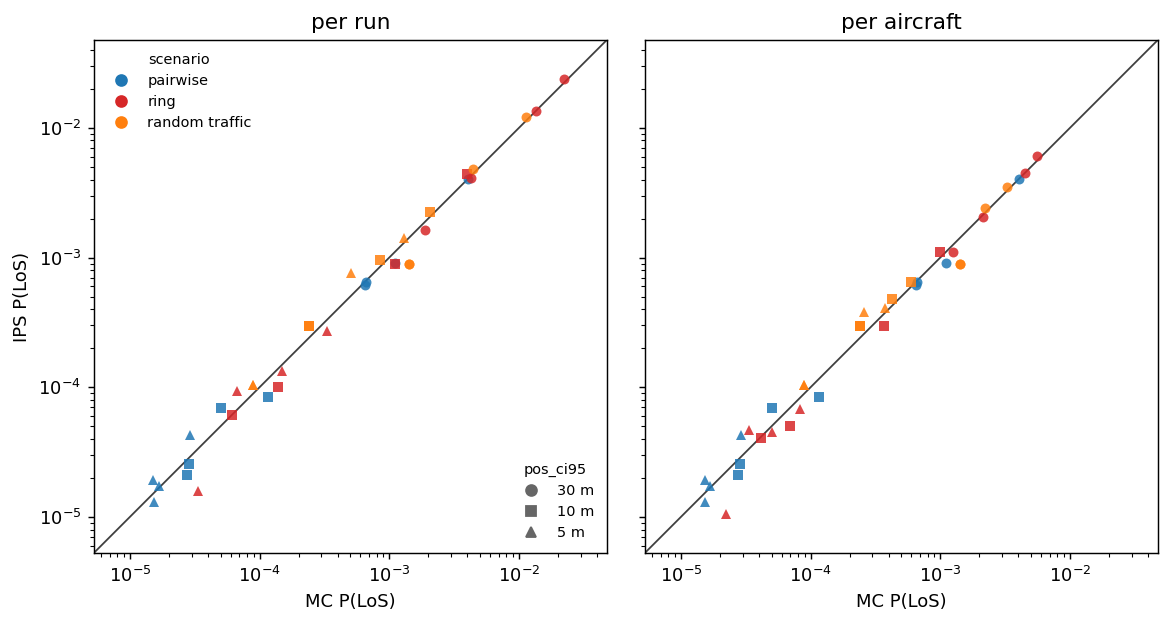

In [3]:
cols = ["mc_p", "ips_p", "mc_p_ac", "ips_p_ac"]
lo = min(df[c].min() for c in cols) * 0.5
hi = max(df[c].max() for c in cols) * 2.0
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.6), sharey=True)
for ax, (x, y, title) in zip(axes, [("mc_p", "ips_p", "per run"),
                                    ("mc_p_ac", "ips_p_ac", "per aircraft")]):
    ax.plot([lo, hi], [lo, hi], color="0.25", lw=1.0)
    for _, r in df.iterrows():
        ax.plot(r[x], r[y], RUNG_MARKER.get(r["rung"], "D"), ms=5.5, mew=0,
                color=PART_COLOR[r["part"]], alpha=0.85)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("MC P(LoS)")
    ax.set_title(title)
    ax.set_box_aspect(1)
axes[0].set_ylabel("IPS P(LoS)")
from matplotlib.lines import Line2D
scenario_handles = [Line2D([], [], marker="o", ls="", color=PART_COLOR[p],
                           label=p.replace("_", " ")) for p in PART_COLOR]
rung_handles = [Line2D([], [], marker=m, ls="", color="0.4", label=f"{r:.0f} m")
                for r, m in RUNG_MARKER.items()]
leg = axes[0].legend(handles=scenario_handles, title="scenario", frameon=False,
                     fontsize=8, title_fontsize=8, loc="upper left")
axes[0].add_artist(leg)
axes[0].legend(handles=rung_handles, title="pos_ci95", frameon=False,
               fontsize=8, title_fontsize=8, loc="lower right")
fig.tight_layout()


Every one of the 36 conditions sits within a factor of two of the line except the deepest ring
cell, and even that one stays inside the factor of five that ADR 0022 accepts below 1e-4. The
two panels tell the same story, which is the point of the tail leg: the per-aircraft number is
measured, not assumed, and it agrees too. Worst per-run ratio: 2.12 at ring `n=3`, 5 m, on an
IPS estimate with 4 of 10 replications collapsed. Median ratio across the campaign: 1.18.


## The price of rarity

Cost is part of the result. Each condition records the wall seconds of both estimators on the
same 100 workers, and `gain` is their ratio. MC's cost to 50 events scales as 1/P(LoS); the IPS
budget is flat, 2,000 particles times 10 replications whatever the probability. The crossover
is where the event becomes rare enough that flying encounters is the expensive way to see one.


campaign totals: MC 10,624 s, IPS 3,384 s


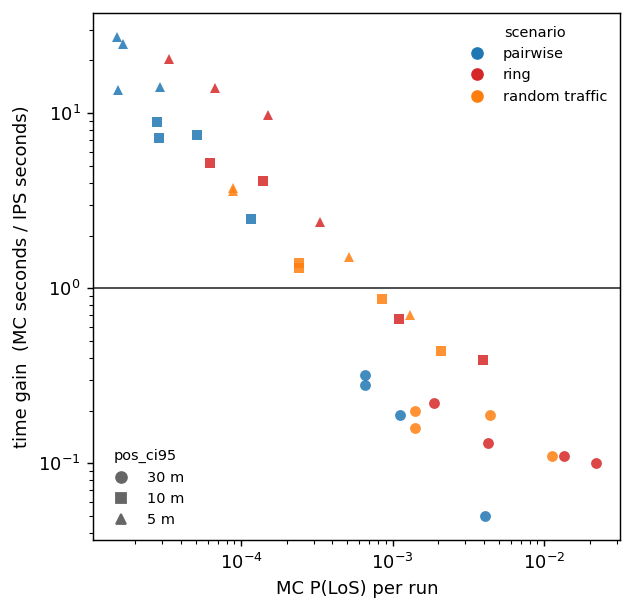

In [4]:
fig, ax = plt.subplots(figsize=(6.4, 4.8))
for _, r in df.iterrows():
    ax.plot(r["mc_p"], r["gain"], RUNG_MARKER.get(r["rung"], "D"), ms=6, mew=0,
            color=PART_COLOR[r["part"]], alpha=0.85)
ax.axhline(1.0, color="0.25", lw=1.0)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("MC P(LoS) per run")
ax.set_ylabel("time gain  (MC seconds / IPS seconds)")
ax.set_box_aspect(1)
from matplotlib.lines import Line2D
scenario_handles = [Line2D([], [], marker="o", ls="", color=PART_COLOR[p],
                           label=p.replace("_", " ")) for p in PART_COLOR]
rung_handles = [Line2D([], [], marker=m, ls="", color="0.4", label=f"{r:.0f} m")
                for r, m in RUNG_MARKER.items()]
leg = ax.legend(handles=scenario_handles, title="scenario", frameon=False,
                fontsize=8, title_fontsize=8, loc="upper right")
ax.add_artist(leg)
ax.legend(handles=rung_handles, title="pos_ci95", frameon=False,
          fontsize=8, title_fontsize=8, loc="lower left")
fig.tight_layout()
mc_total = df["mc_s"].sum(); ips_total = df["ips_s"].sum()
print(f"campaign totals: MC {mc_total:,.0f} s, IPS {ips_total:,.0f} s")


The crossover sits near P(LoS) of 2e-4. Above it MC is unbeatable, a 30 m pairwise cell costs
it 3 s against IPS's 48 s. Below it the roles reverse and the gap widens with rarity: at the
5 m rung MC pays 378 s to 1,233 s per fleet cell and up to 1,140 s for a pair, while IPS stays
between 41 s and 158 s everywhere, and the best cells reach a gain of 20 to 27. Note the fleet
effect on the right edge: a dense fleet's per-run probability is never rare, so its gain stays
below one even at the 5 m rung. Splitting earns its keep on the per-run rarity, not on the
noise rung.


## Weak points, named

Three rows deserve their caveats stated rather than averaged away.

**Ring `n=3` at 5 m.** Four of ten replications collapsed and the survival of the last shell
was 0.013, so the estimate leans on six replications and reads 2.1 times under the anchor,
inside the factor-five rule but the worst row of the campaign. The deep shells of a fixed
ladder are placed by extrapolation below what a 200-encounter pilot can see, and this row is
what that looks like when it bites.

**Random densities 0.1 and 0.2.** Both round to the 2-aircraft minimum on this disc, so the two
rows are one condition under two labels, at a realized density of 0.28 per km². They are also
the only band violation. A future sweep should pick densities that map to distinct aircraft
counts, or declare `n` directly.

**Collapsed replications elsewhere.** Thirteen of 360 replications collapsed, all but one
at the 5 m rung, and every collapse is visible in its row rather than silently absorbed. A collapse
contributes the zero it found, which biases those means low and is the honest reading of a
ladder spaced too aggressively for its condition.


## What this licenses

At the anchor rung, where MC rests on 50 to 79 events per condition, the two estimators agree
within noise on all twelve conditions, per run and per aircraft. That agreement is the licence
for the rarer rungs: the same code, the same encounter distribution and the same shells produce
the IPS numbers at 10 m and 5 m, where MC needs millions of encounters and twenty minutes per
condition to check a single point. Where the per-run probability is rare, splitting delivers
the same answer ten to twenty-seven times cheaper. Where it is not rare, this library's answer
is to use MC, and the campaign's gain column says so out loud.
